In [1]:
import pandas
X_train = pandas.read_csv('..\\..\\..\\dataset\\Pirate\\pirate_pain_train.csv')
y_train = pandas.read_csv('..\\..\\..\\dataset\\Pirate\\pirate_pain_train_labels.csv')

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

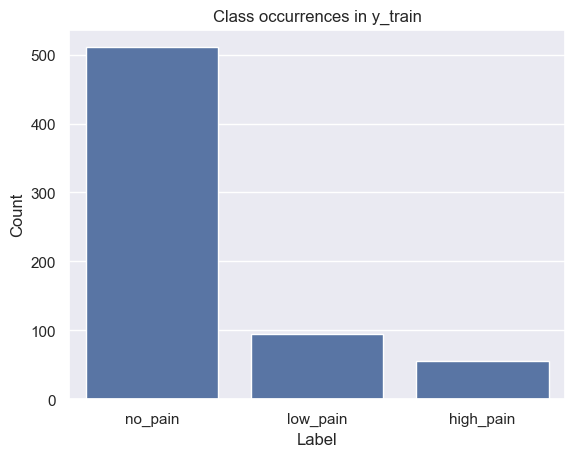

In [3]:
counts = y_train['label'].value_counts()
sns.countplot(x='label', data=y_train, order=counts.index)
plt.title('Class occurrences in y_train')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

We can drop the last column because it is constant:

In [4]:
mask = X_train['joint_30'] != 0.5
count = mask.sum()
print("Rows where joint_30 != 0.5:", count)

Rows where joint_30 != 0.5: 0


The three columns 'n_eyes', 'n_hands', and 'n_legs' have the same distribution, so we can drop two of them:

In [5]:

print("dtype:", X_train['n_eyes'].dtype)
print("Unique values:", X_train['n_eyes'].unique())
print("\nCounts:\n", X_train['n_eyes'].value_counts(dropna=False))

print("dtype:", X_train['n_legs'].dtype)
print("Unique values:", X_train['n_legs'].unique())
print("\nCounts:\n", X_train['n_legs'].value_counts(dropna=False))

print("dtype:", X_train['n_hands'].dtype)
print("Unique values:", X_train['n_hands'].unique())
print("\nCounts:\n", X_train['n_hands'].value_counts(dropna=False))



dtype: object
Unique values: ['two' 'one+eye_patch']

Counts:
 n_eyes
two              104800
one+eye_patch       960
Name: count, dtype: int64
dtype: object
Unique values: ['two' 'one+peg_leg']

Counts:
 n_legs
two            104800
one+peg_leg       960
Name: count, dtype: int64
dtype: object
Unique values: ['two' 'one+hook_hand']

Counts:
 n_hands
two              104800
one+hook_hand       960
Name: count, dtype: int64


In [6]:
X_train.loc[
    (X_train['n_eyes'] == 'two') &
    (X_train['n_hands'] == 'two') &
    (X_train['n_legs'] == 'two')
].shape[0]


104800

In [7]:
cleaned_X_train = X_train.drop(columns=['n_hands', 'n_legs','joint_30'])

In [8]:
cleaned_X_train.head()

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_eyes,joint_00,joint_01,joint_02,...,joint_20,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29
0,0,0,2,0,2,1,two,1.094705,0.985281,1.018302,...,6.140248e-07,3.499558e-06,1.945042e-06,0.000004,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815
1,0,1,2,2,2,2,two,1.135183,1.021175,0.994343,...,1.931978e-06,3.976952e-07,6.765107e-07,0.000006,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716
2,0,2,2,0,2,2,two,1.080745,0.962842,1.009588,...,5.730838e-07,1.533820e-07,1.698525e-07,0.000001,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105
3,0,3,2,2,2,2,two,0.938017,1.081592,0.998021,...,3.677486e-05,1.006865e-05,5.511079e-07,0.000002,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648
4,0,4,2,2,2,2,two,1.090185,1.032145,1.008710,...,2.037939e-05,4.437266e-06,1.735459e-07,0.000002,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328


In [9]:
grouped = cleaned_X_train.groupby('sample_index')
grouped.head()
#count rows per group
grouped.size()

sample_index
0      160
1      160
2      160
3      160
4      160
      ... 
656    160
657    160
658    160
659    160
660    160
Length: 661, dtype: int64

In [10]:
for name, group in grouped:
    print(grouped['n_eyes'].value_counts())

sample_index  n_eyes
0             two       160
1             two       160
2             two       160
3             two       160
4             two       160
                       ... 
656           two       160
657           two       160
658           two       160
659           two       160
660           two       160
Name: count, Length: 661, dtype: int64
sample_index  n_eyes
0             two       160
1             two       160
2             two       160
3             two       160
4             two       160
                       ... 
656           two       160
657           two       160
658           two       160
659           two       160
660           two       160
Name: count, Length: 661, dtype: int64
sample_index  n_eyes
0             two       160
1             two       160
2             two       160
3             two       160
4             two       160
                       ... 
656           two       160
657           two       160
658           two  

In [13]:
#divide the dataset between labels
high_pain_indices = y_train[y_train['label'] == 'high_pain']['sample_index'].unique()
no_pain_indices = y_train[y_train['label'] == 'no_pain']['sample_index'].unique()
low_pain_indices = y_train[y_train['label'] == 'low_pain']['sample_index'].unique()
high_pain_data = cleaned_X_train[cleaned_X_train['sample_index'].isin(high_pain_indices)]
no_pain_data = cleaned_X_train[cleaned_X_train['sample_index'].isin(no_pain_indices)]
low_pain_data = cleaned_X_train[cleaned_X_train['sample_index'].isin(low_pain_indices)]

In [14]:
grouped_high = high_pain_data.groupby('sample_index')
grouped_no = no_pain_data.groupby('sample_index')
grouped_low = low_pain_data.groupby('sample_index')


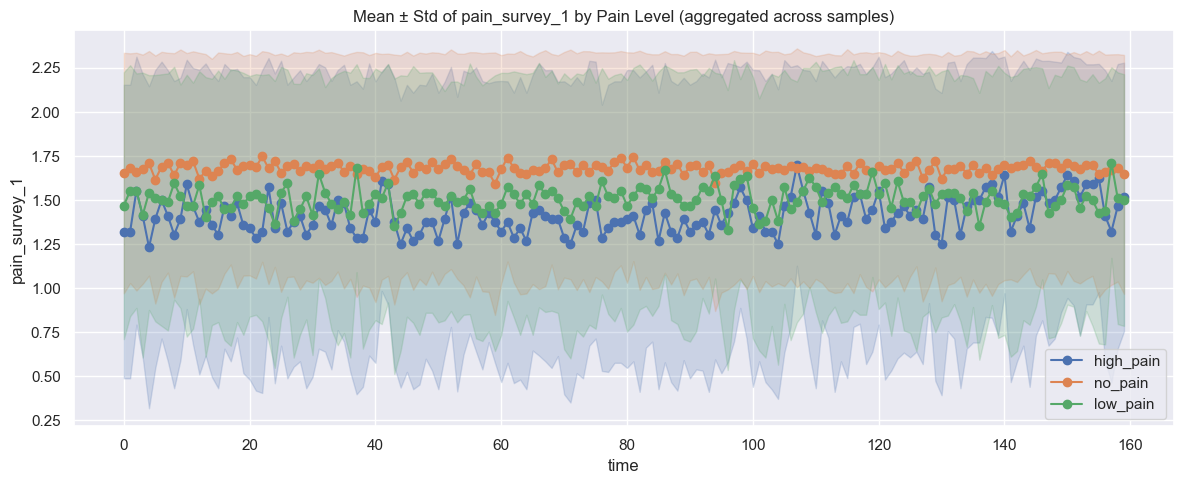

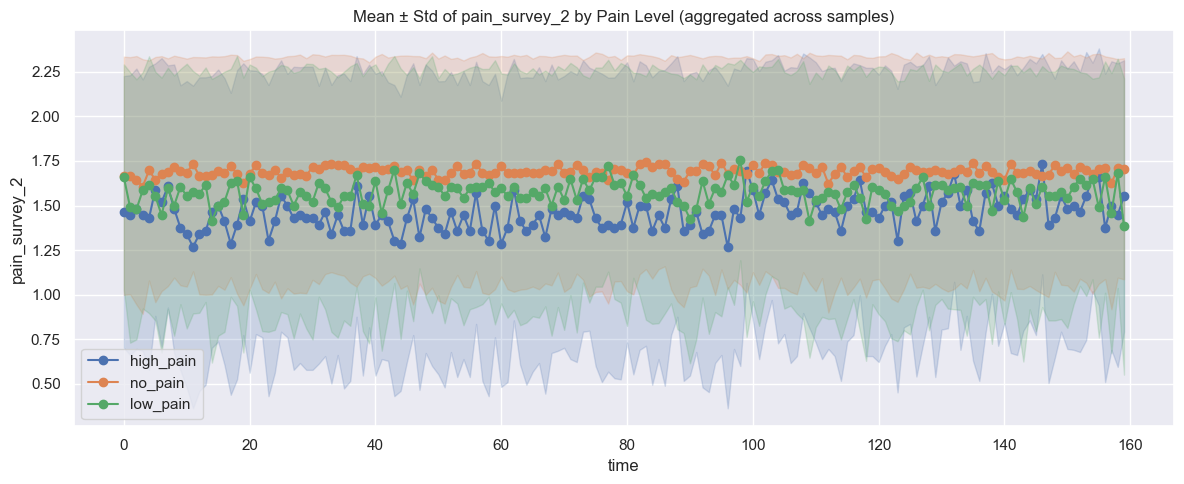

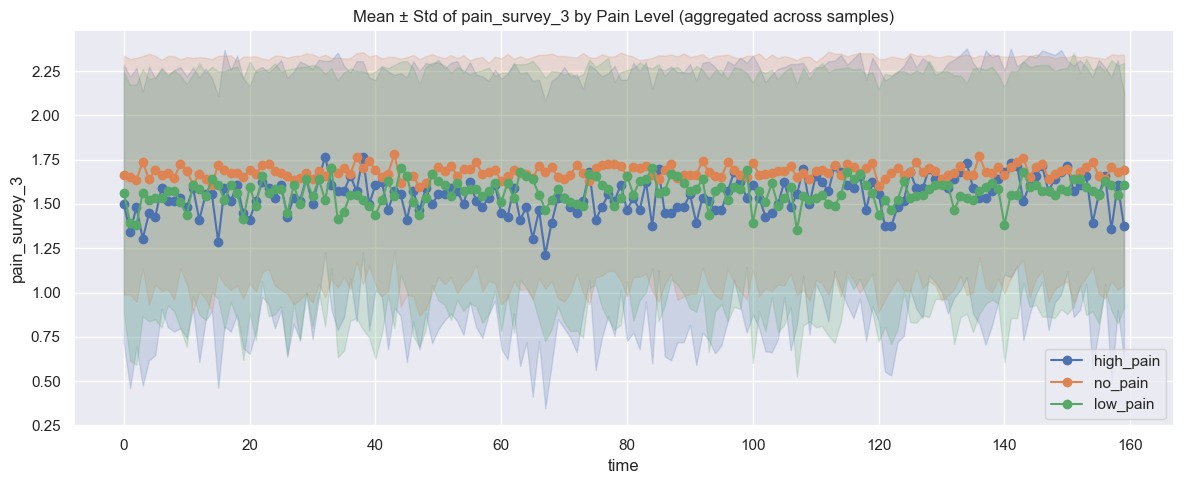

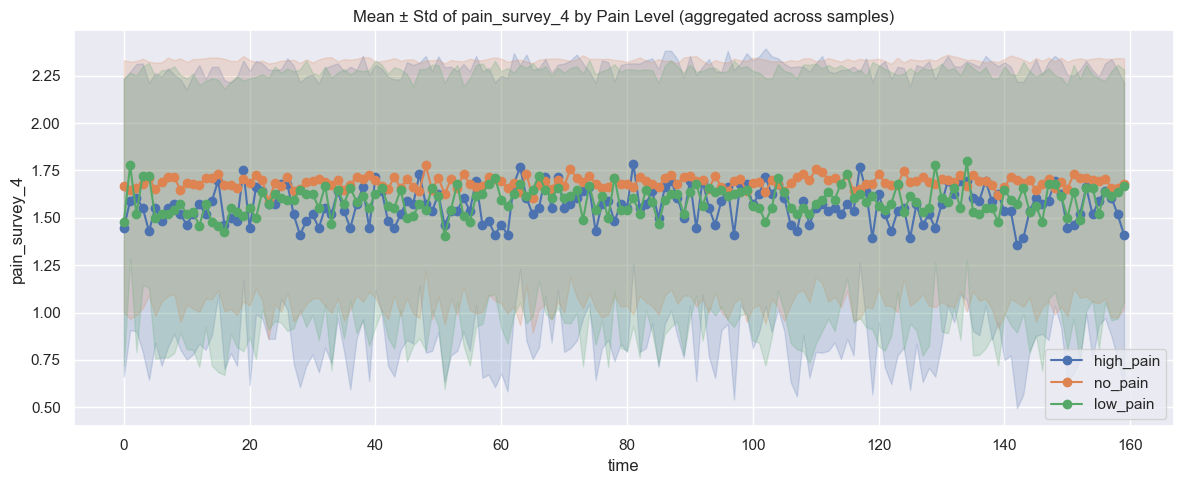

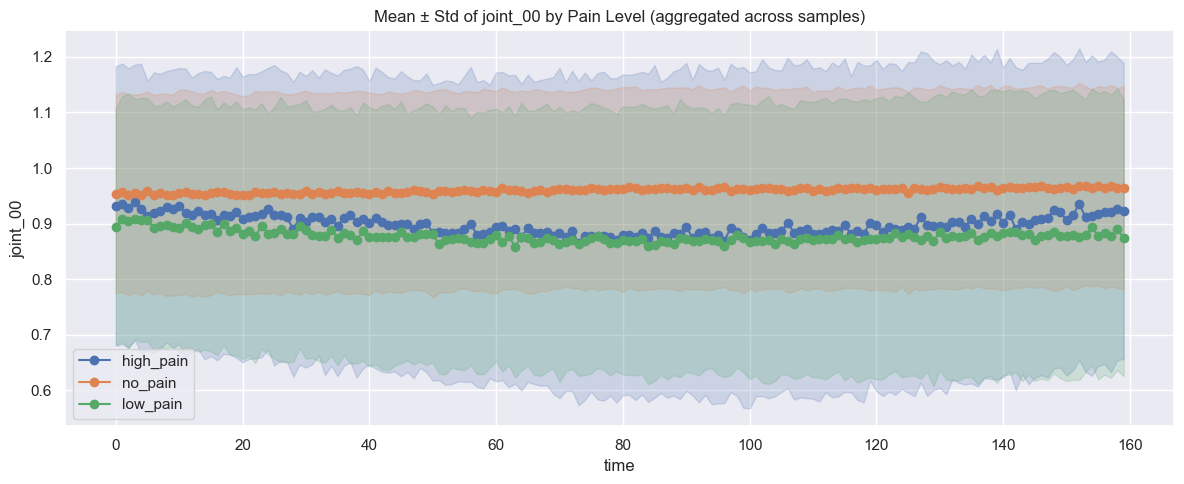

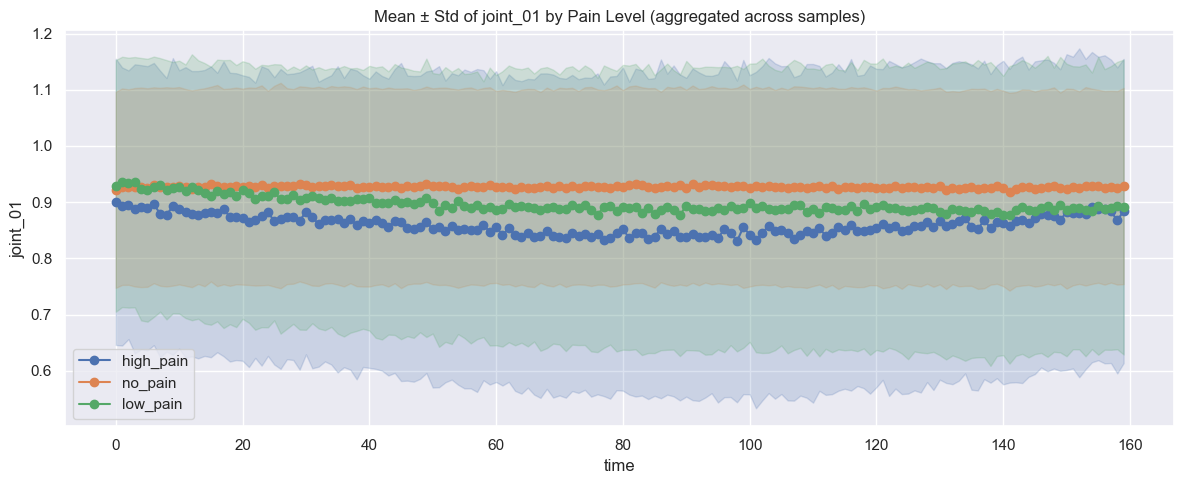

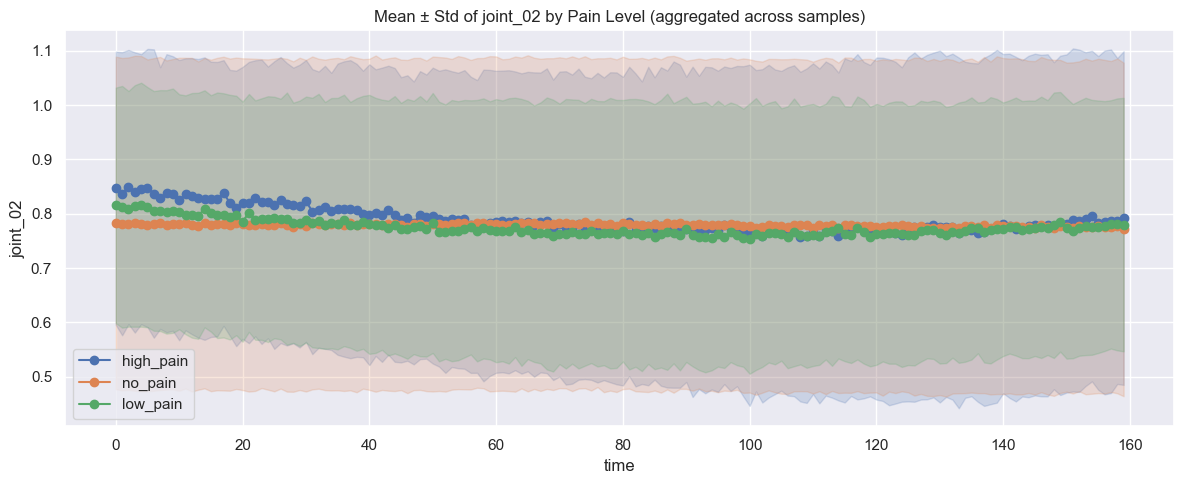

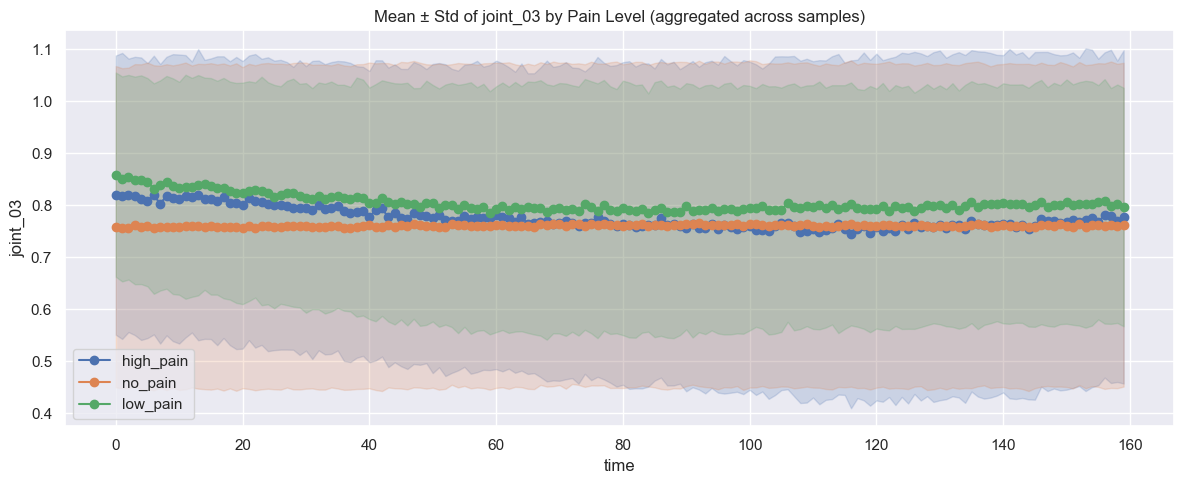

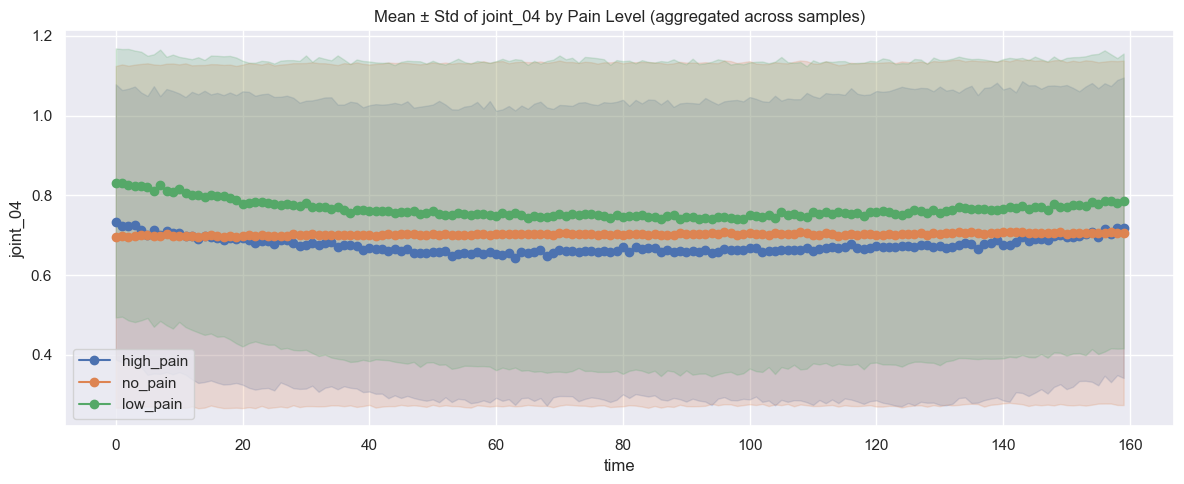

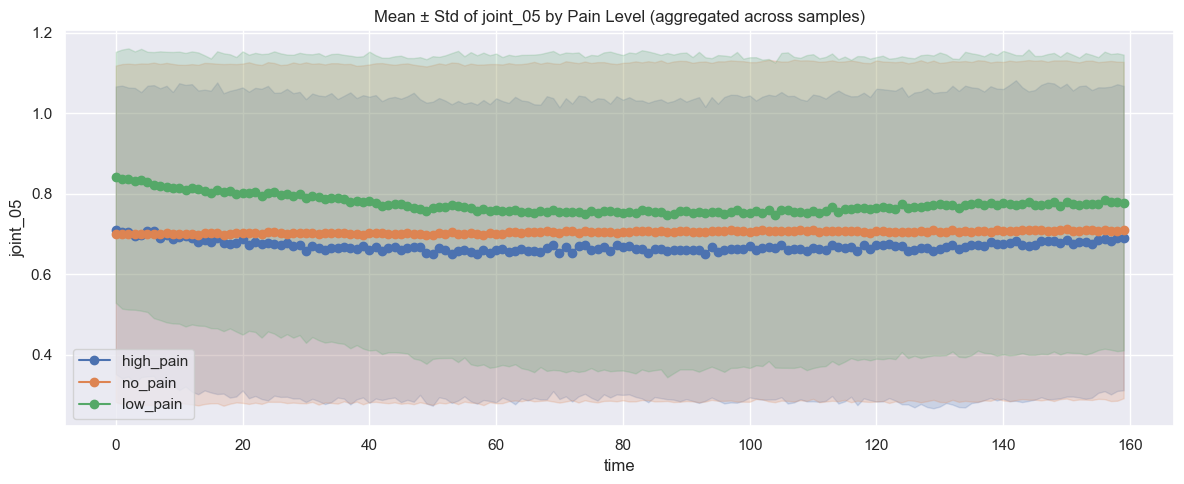

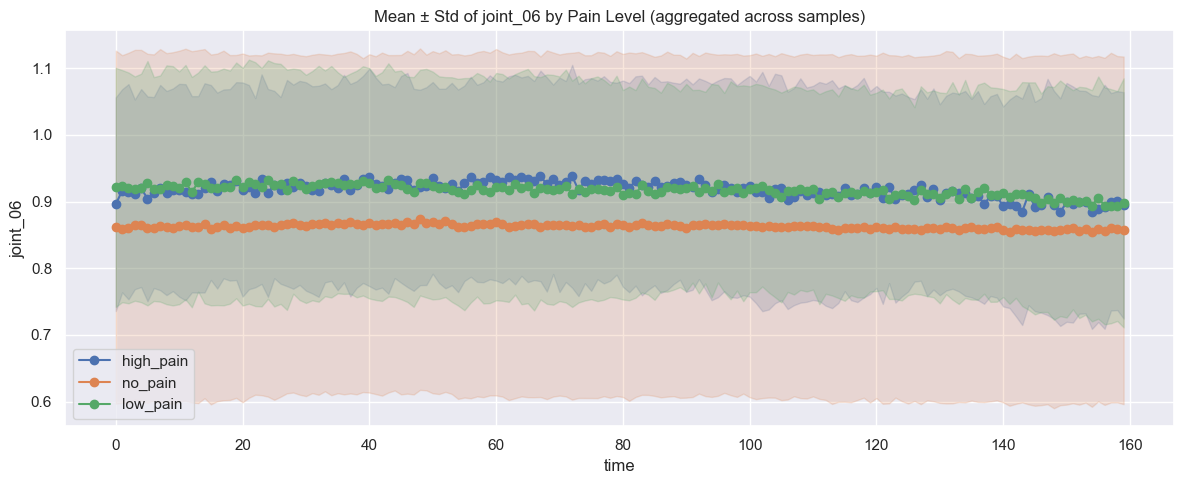

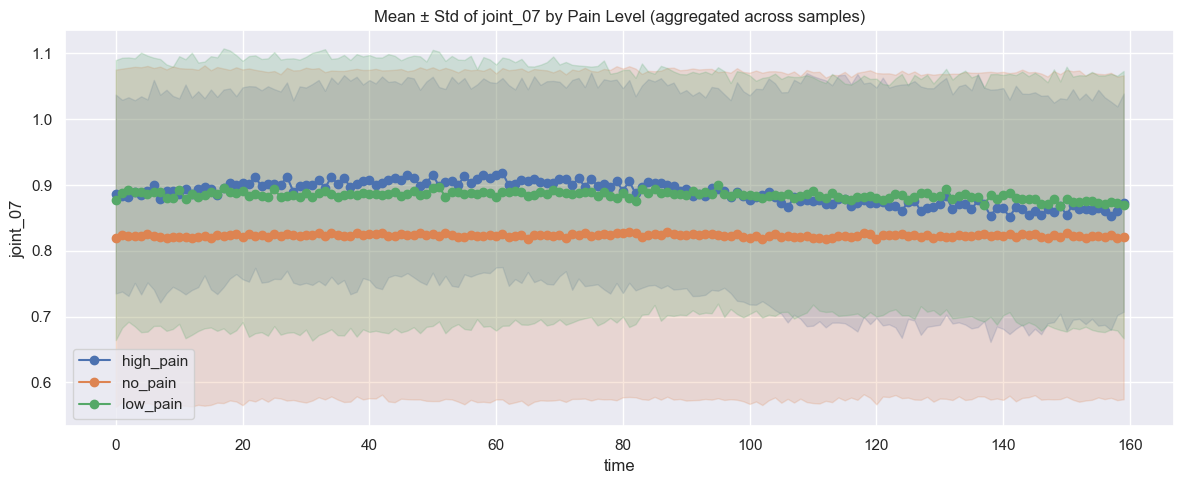

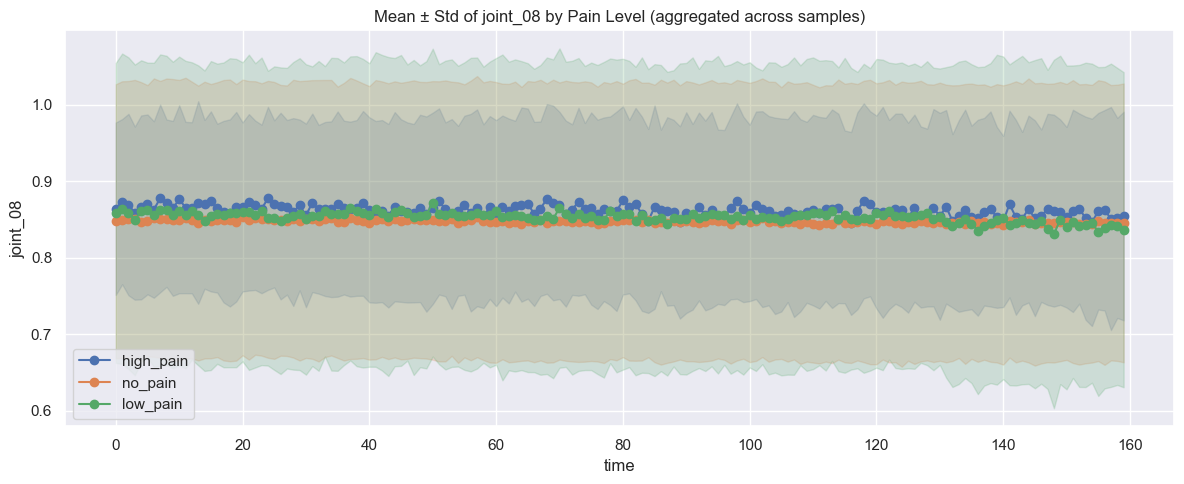

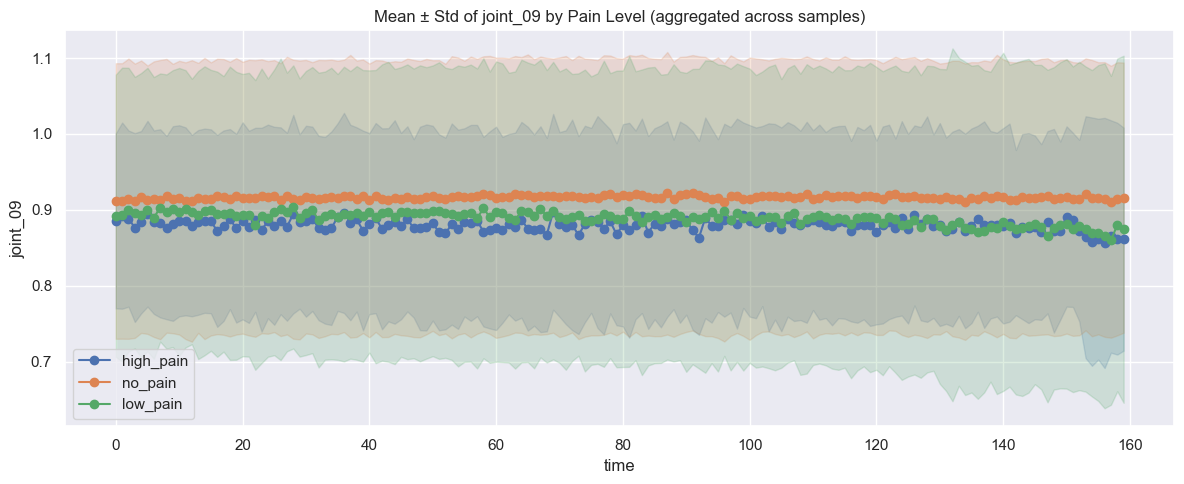

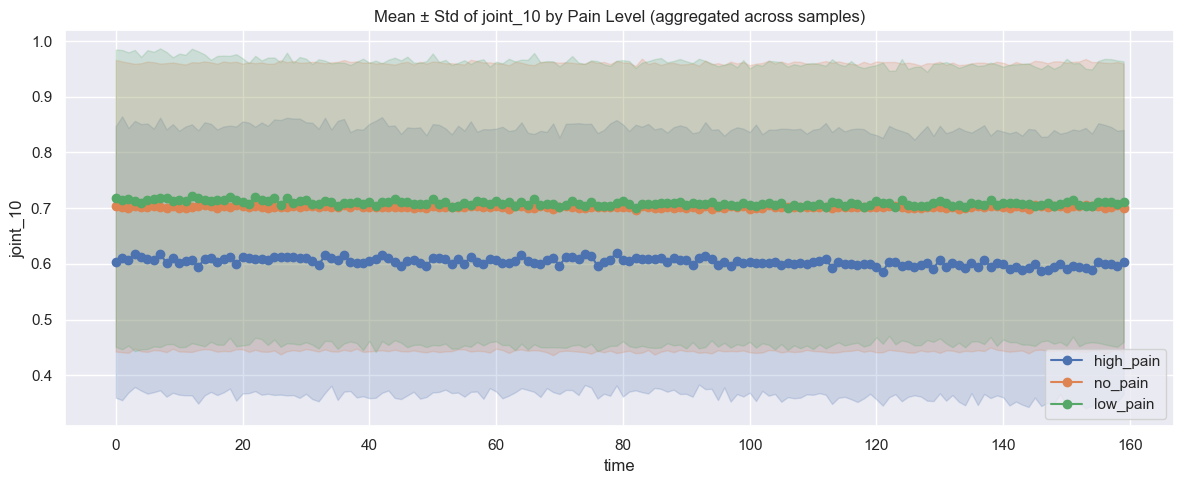

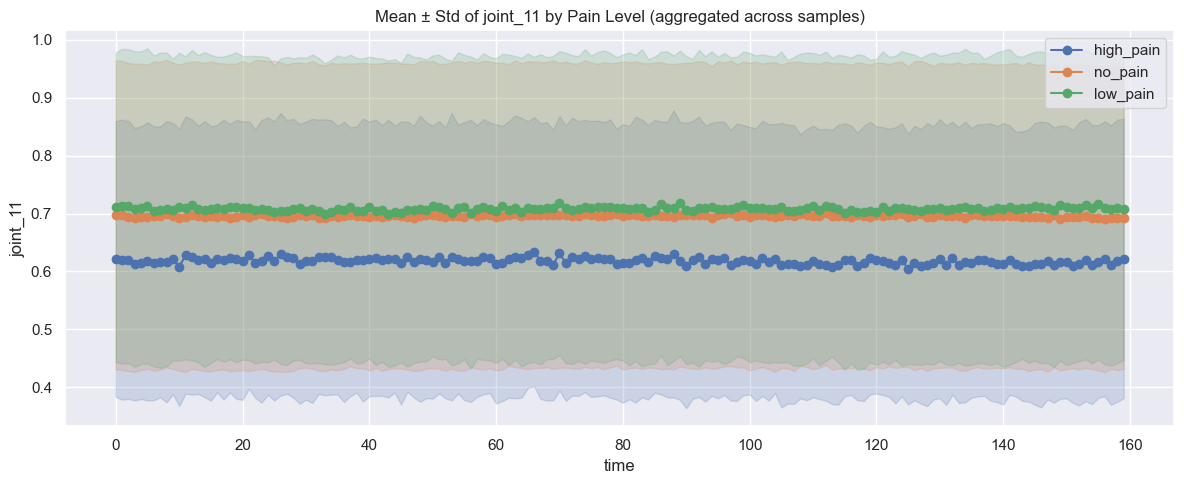

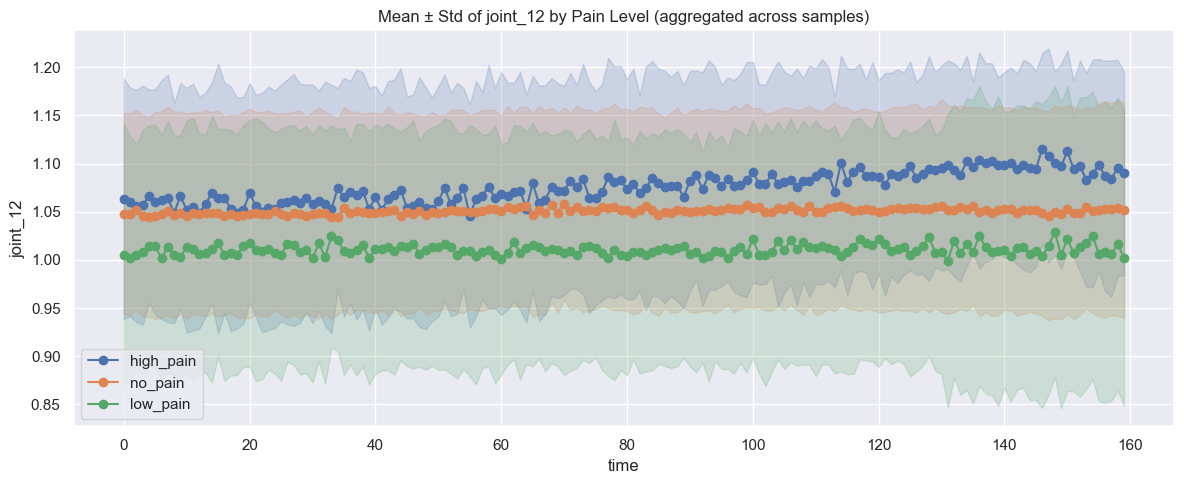

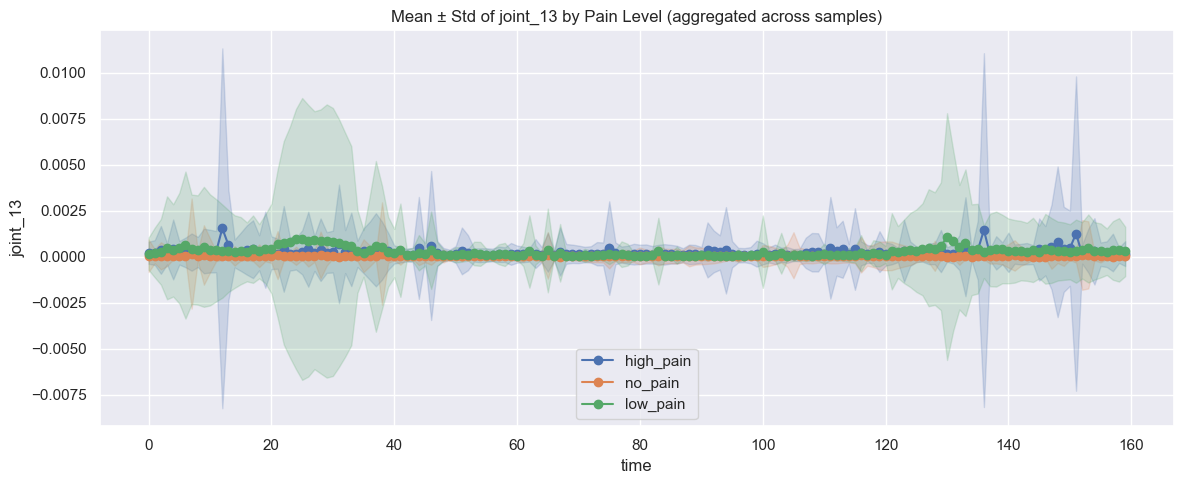

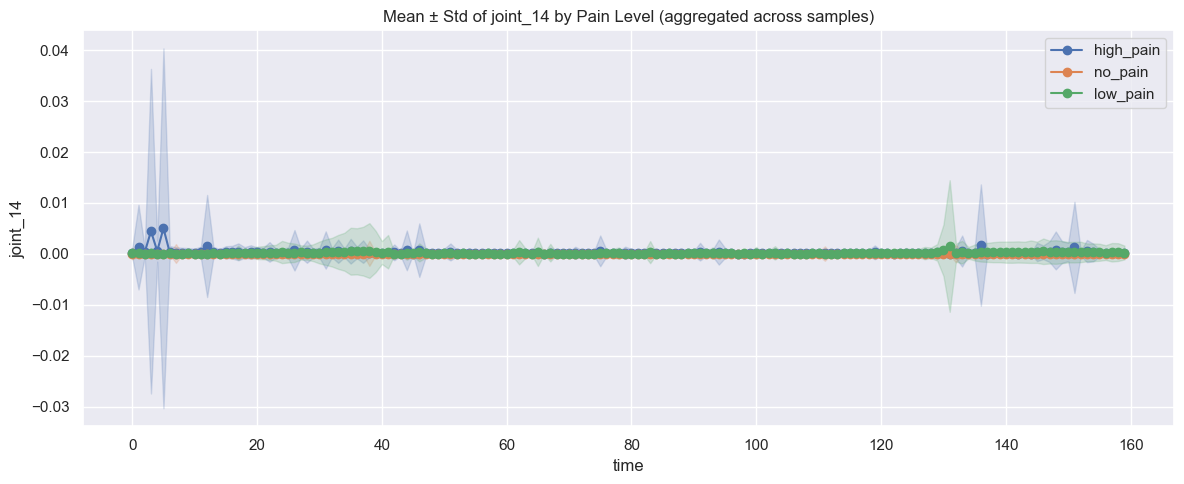

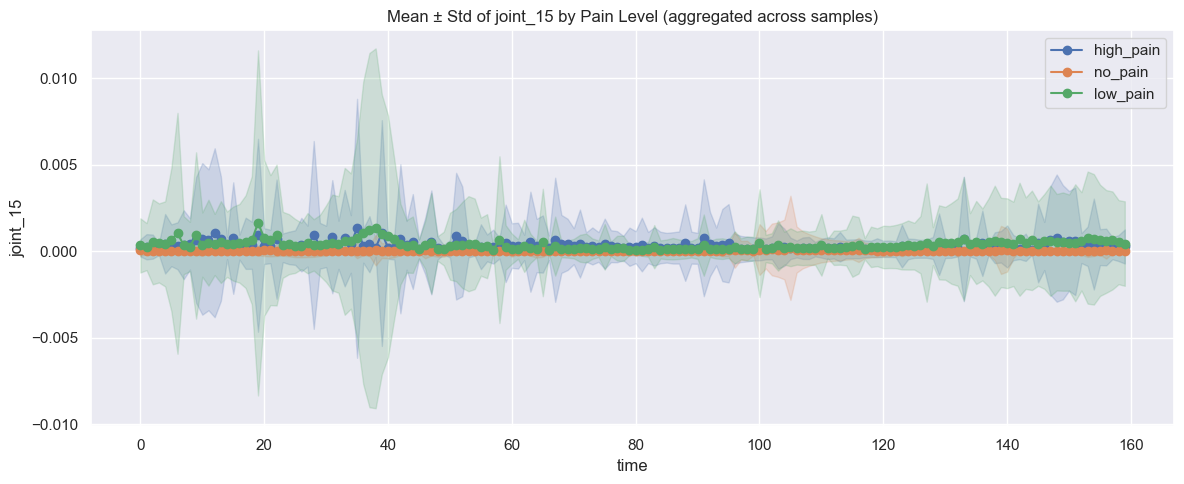

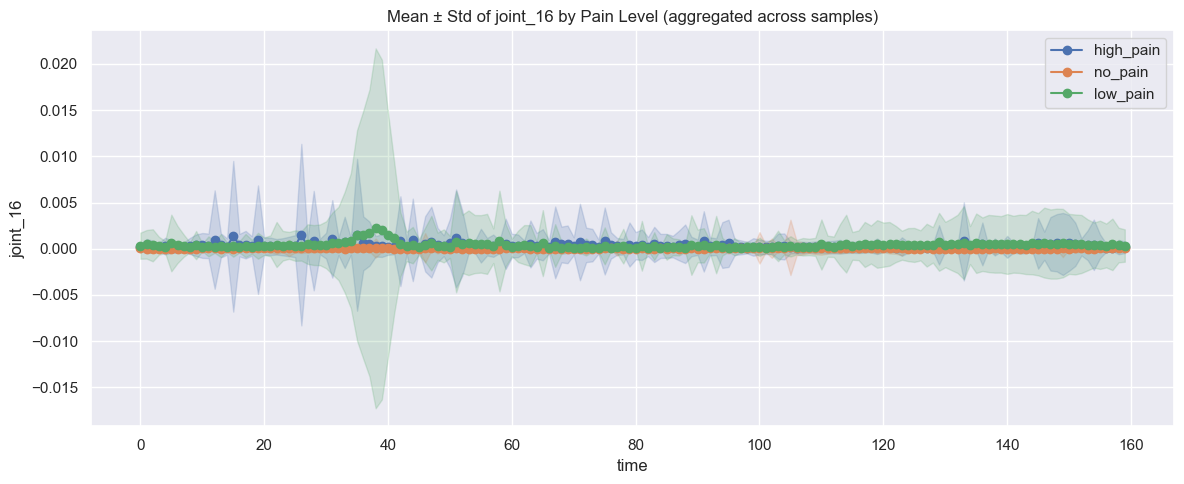

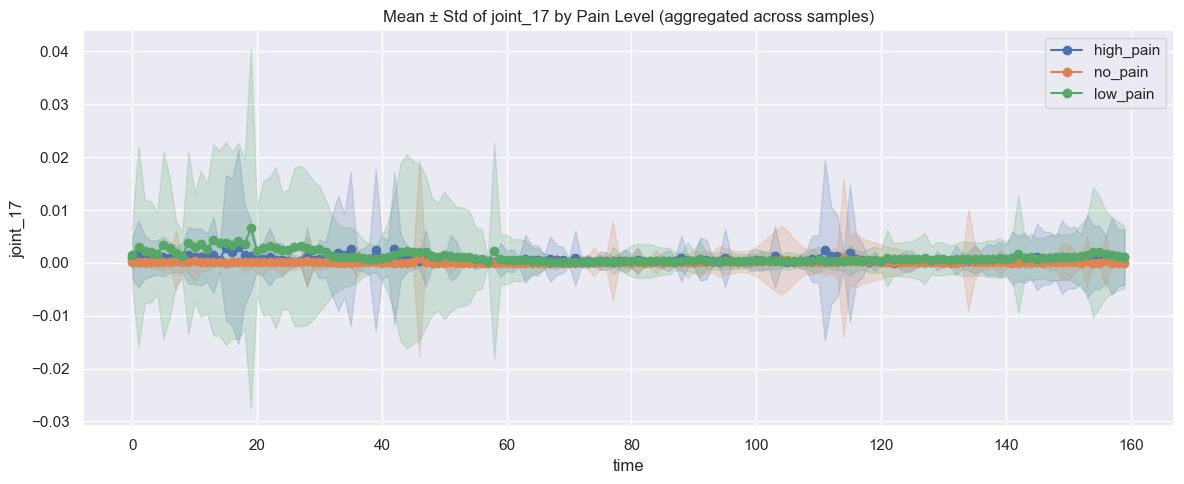

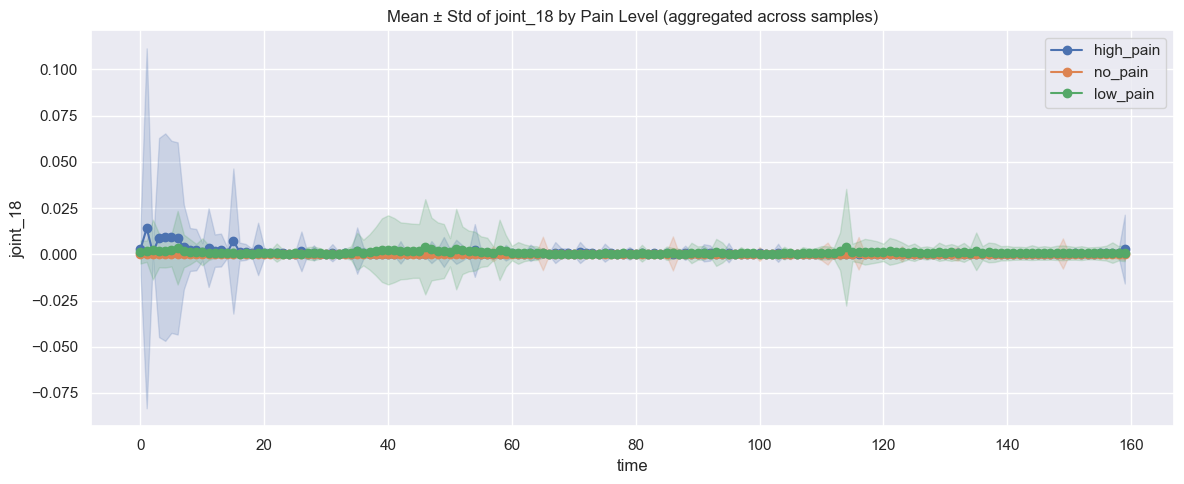

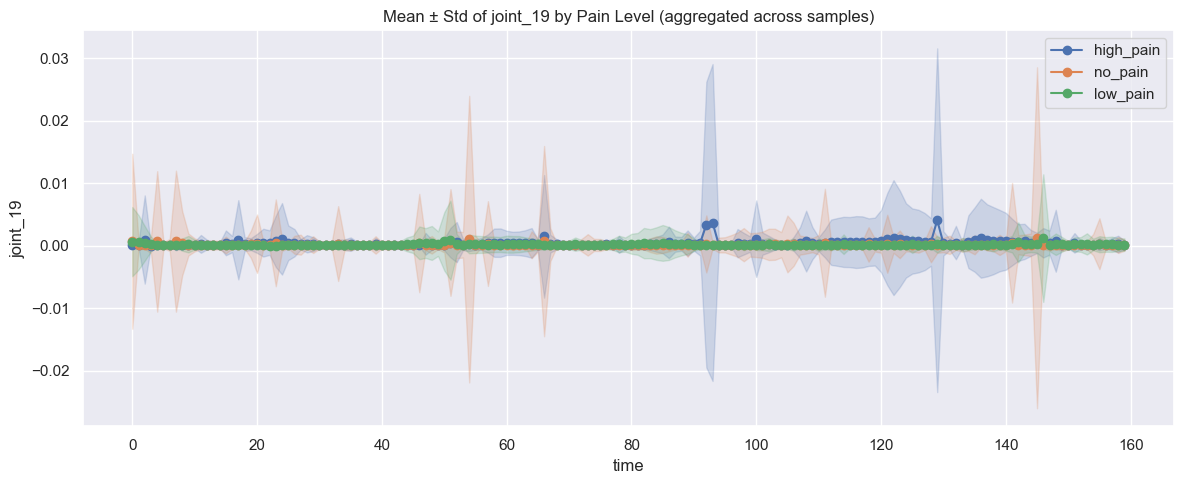

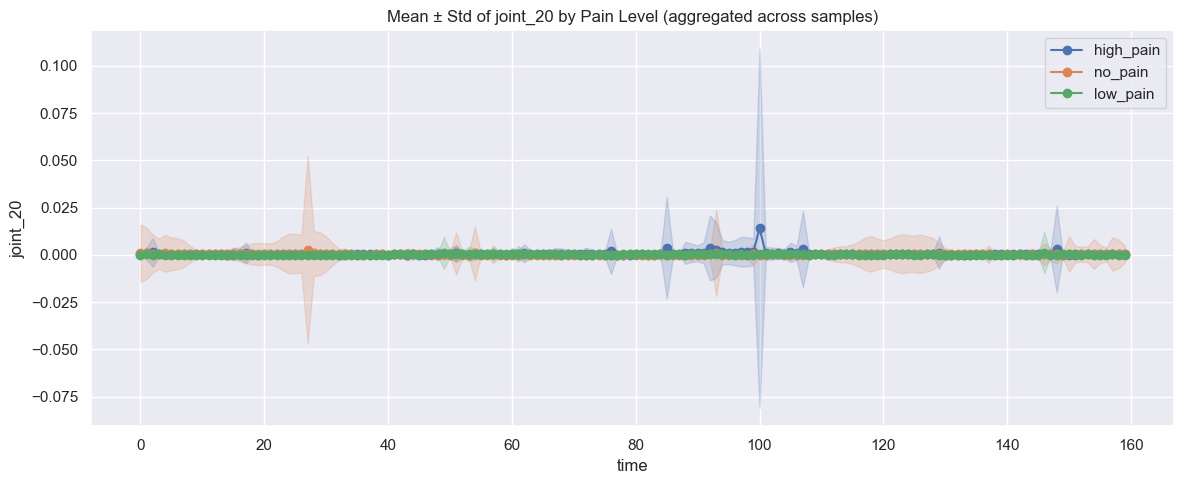

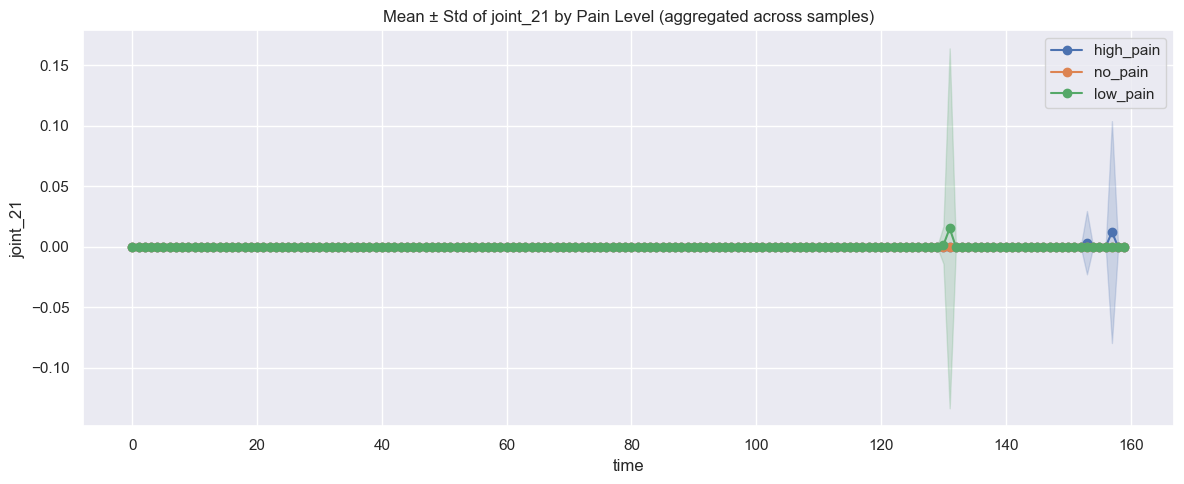

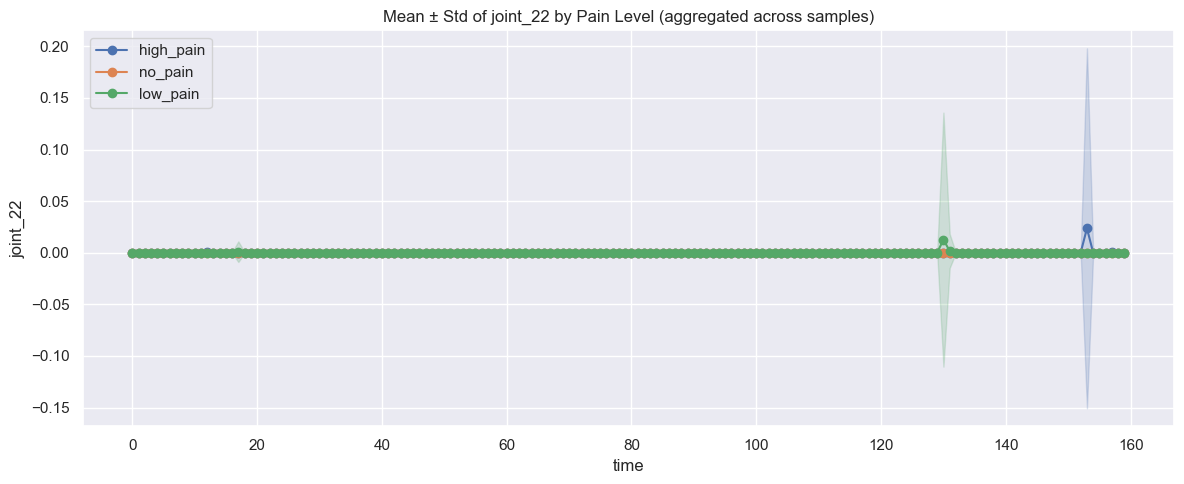

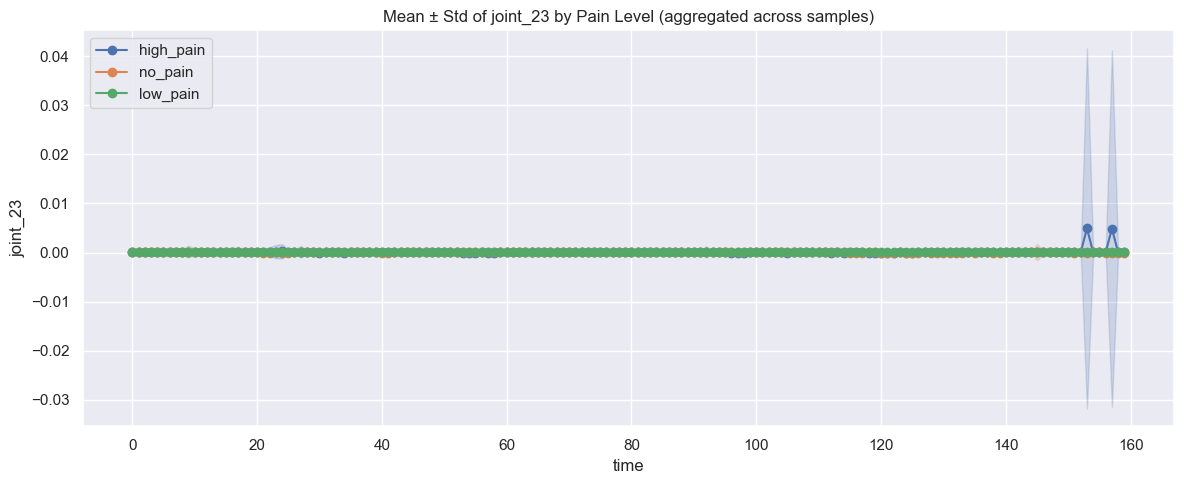

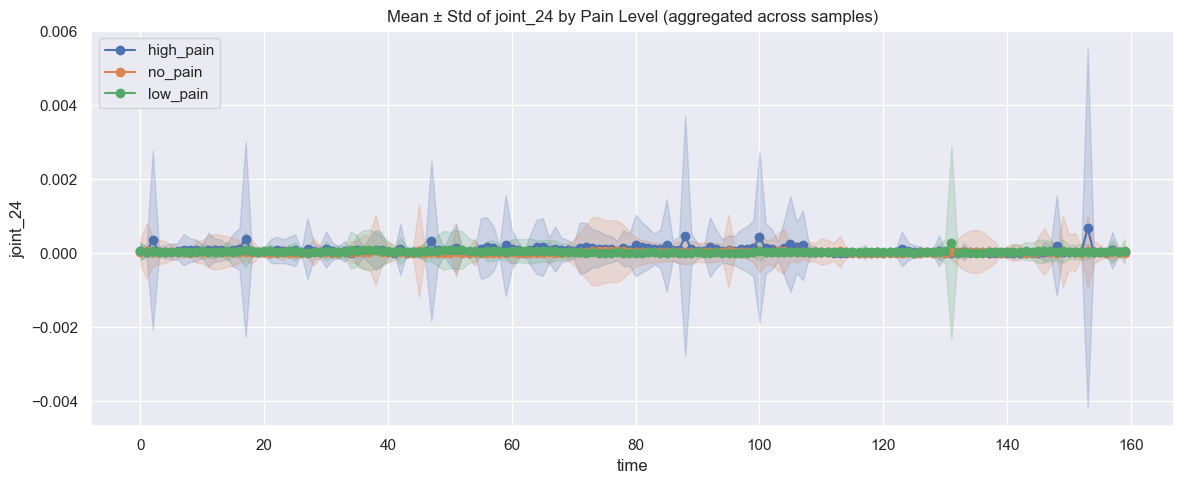

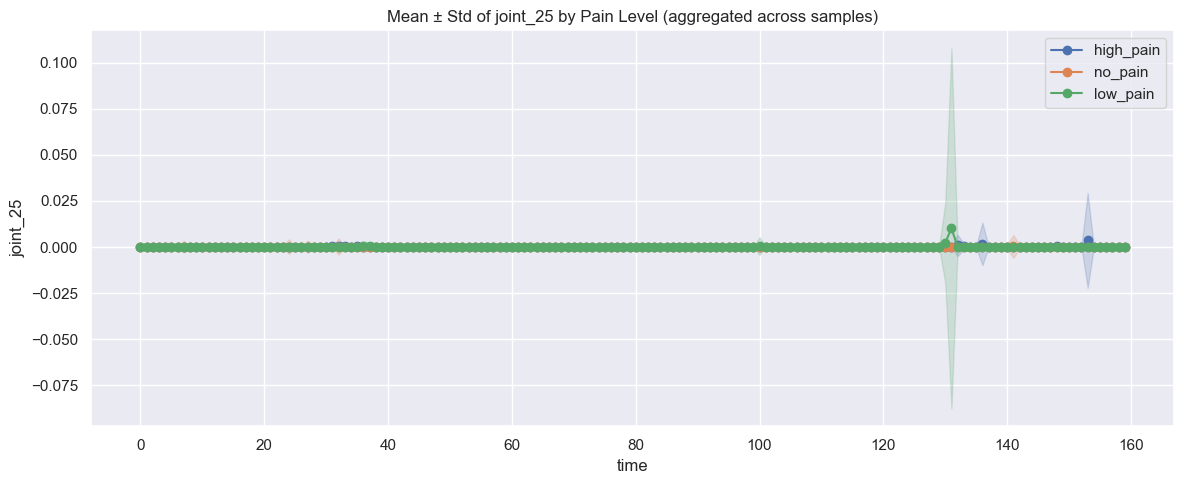

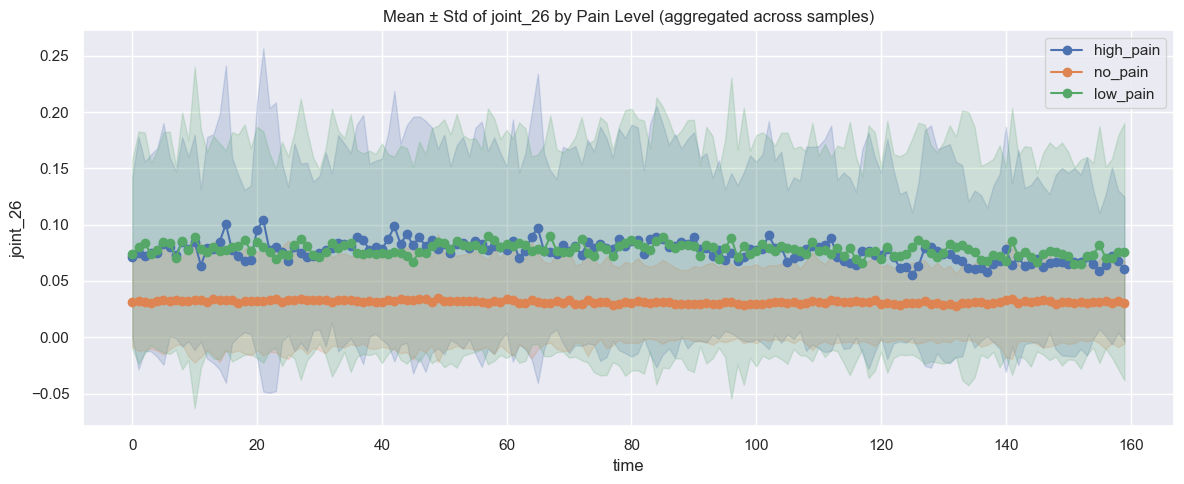

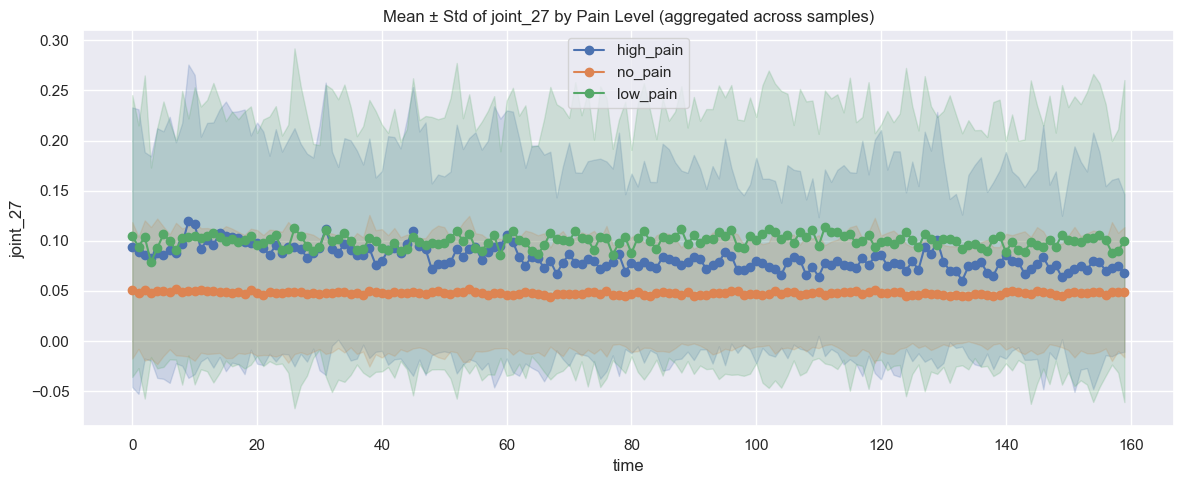

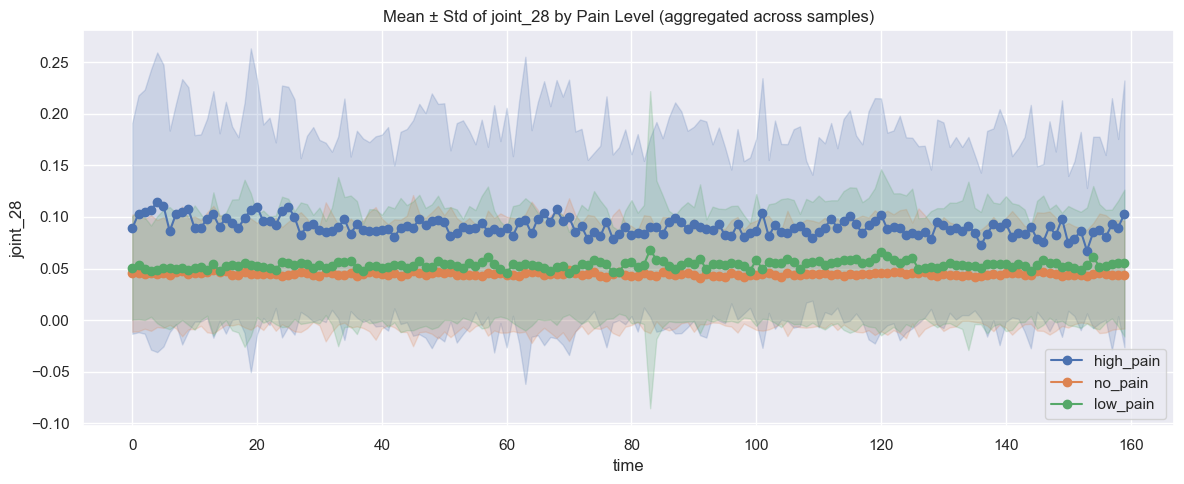

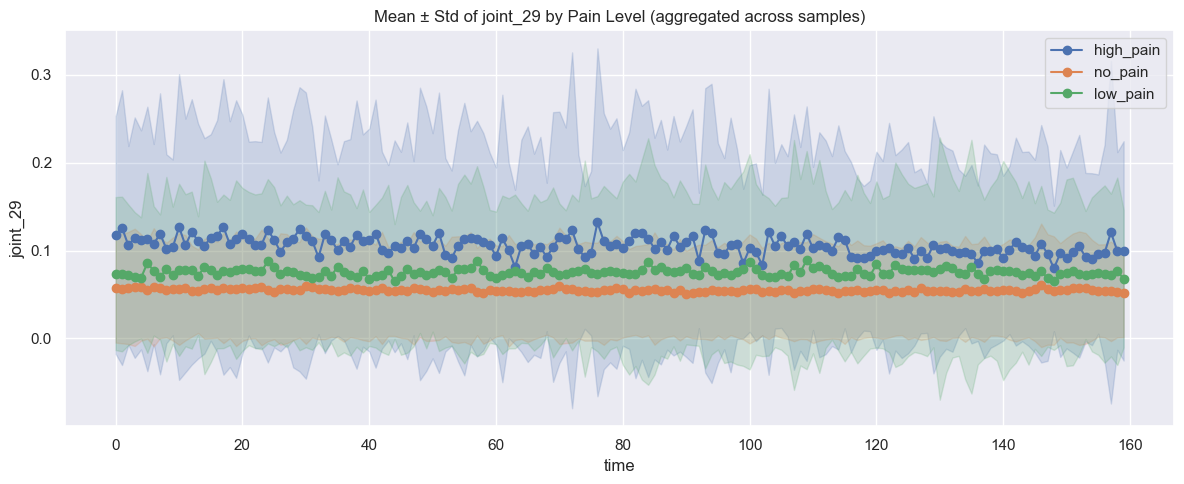

In [40]:
timeseries_columns = [c for c in cleaned_X_train.columns if c not in ['sample_index', 'time', 'n_eyes']]
for col in timeseries_columns:
    plt.figure(figsize=(12, 5))
    high_mean = high_pain_data.groupby('time')[col].mean().sort_index()
    high_std  = high_pain_data.groupby('time')[col].std().sort_index()
    no_mean   = no_pain_data.groupby('time')[col].mean().sort_index()
    no_std    = no_pain_data.groupby('time')[col].std().sort_index()
    low_mean  = low_pain_data.groupby('time')[col].mean().sort_index()
    low_std   = low_pain_data.groupby('time')[col].std().sort_index()

    plt.plot(high_mean.index, high_mean, label='high_pain', color='C0', marker='o')
    plt.fill_between(high_mean.index, high_mean - high_std, high_mean + high_std, color='C0', alpha=0.2)

    plt.plot(no_mean.index, no_mean, label='no_pain', color='C1', marker='o')
    plt.fill_between(no_mean.index, no_mean - no_std, no_mean + no_std, color='C1', alpha=0.2)

    plt.plot(low_mean.index, low_mean, label='low_pain', color='C2', marker='o')
    plt.fill_between(low_mean.index, low_mean - low_std, low_mean + low_std, color='C2', alpha=0.2)

    plt.title(f'Mean ± Std of {col} by Pain Level (aggregated across samples)')
    plt.xlabel('time')
    plt.ylabel(col)
    plt.legend()
    plt.tight_layout()
    plt.show()